In [1]:
import sys
sys.path.append('/home/james/ml-proj/predmain/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef

from features import engineer_features, get_feature_columns, get_target_column
from models import build_model, get_class_weight
from evaluate import evaluate_model, plot_confusion_matrix

sns.set_theme(style='darkgrid')

df = pd.read_csv('/home/james/ml-proj/predmain/data/ai4i2020.csv')
df = df.drop(columns=['UDI', 'Product ID', 'Type'], errors='ignore')
df = engineer_features(df)

X = df[get_feature_columns()]
y = df[get_target_column()]

# 80 / 10 / 10 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

weight = get_class_weight(y_train)
print(f"Features : {get_feature_columns()}")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Class weight (scale_pos_weight): 28.52
  (7729 no-failure rows vs 271 failure rows)
Features : ['power_W', 'temp_delta_K', 'tool_wear_min']
Train: 8000 | Val: 1000 | Test: 1000


In [ ]:
from models import build_model, get_class_weight, tune_model

THRESHOLD = 0.35  # probability cut-off for flagging failures

# Hyperparameter tuning — Optuna TPE, 75 trials, optimising MCC via 5-fold CV
tune_results = tune_model(X_train, y_train, scale_pos_weight=weight, n_trials=75)
best_params = tune_results['best_params']

# Cross-validate with tuned params (training set only — val/test never seen)
model_cv = build_model(scale_pos_weight=weight, **best_params)
cv_results = evaluate_model(model_cv, X_train, y_train)
print(f"\nNaive Bayes baseline : MCC 0.235")
print(f"CV improvement       : {cv_results['mcc_mean'] - 0.235:+.3f} MCC")

MCC  (mean ± std): 0.568 ± 0.052
F1   (mean ± std): 0.575 ± 0.045

Naive Bayes baseline: MCC 0.235
CV improvement:       +0.333 MCC


Early stopping: used 750 / 3000 trees

--- Validation set ---


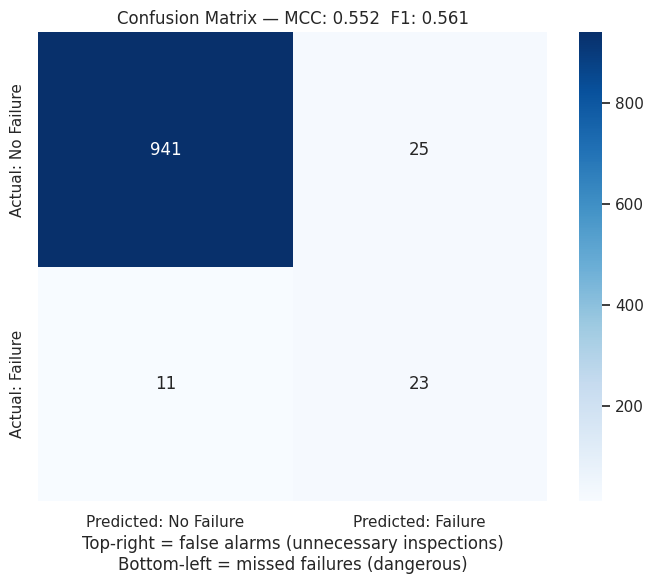

              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98       966
     Failure       0.48      0.68      0.56        34

    accuracy                           0.96      1000
   macro avg       0.73      0.83      0.77      1000
weighted avg       0.97      0.96      0.97      1000

Val MCC improvement over NB baseline: +0.317


In [ ]:
# Final fit with tuned params + early stopping on val set
# Merge: early-stopping overrides take priority over Optuna's n_estimators
final_params = {**best_params, 'n_estimators': 3000, 'early_stopping_rounds': 75}
model = build_model(scale_pos_weight=weight, **final_params)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"Early stopping: used {model.best_iteration} / 3000 trees")

# Validation — use threshold=0.35 to boost recall on failures
print(f"\n--- Validation set (threshold={THRESHOLD}) ---")
val_metrics = plot_confusion_matrix(model, X_val, y_val, threshold=THRESHOLD)
print(f"Val MCC improvement over NB baseline: {val_metrics['mcc'] - 0.235:+.3f}")

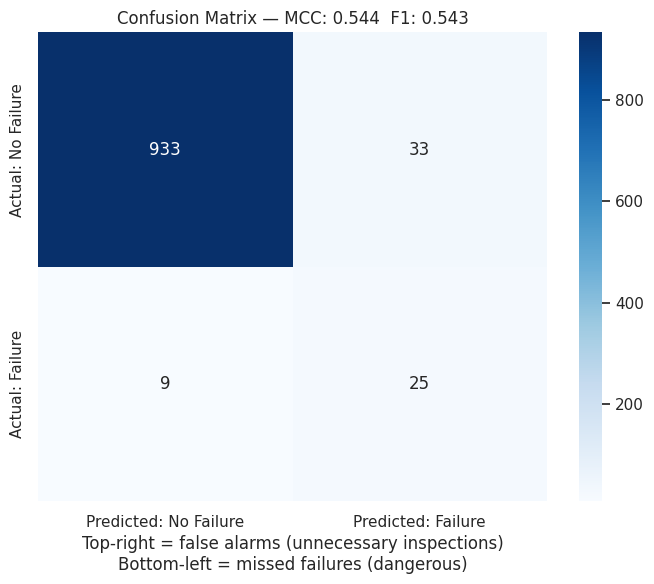

              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98       966
     Failure       0.43      0.74      0.54        34

    accuracy                           0.96      1000
   macro avg       0.71      0.85      0.76      1000
weighted avg       0.97      0.96      0.96      1000


Val  MCC: 0.552  F1: 0.561
Test MCC: 0.544  F1: 0.543
Val → Test gap: -0.008  (OK)


In [4]:
# Q: Where is the model failing on held-out test set — false alarms or missed failures?
test_metrics = plot_confusion_matrix(
    model, X_test, y_test,
    save_path='/home/james/ml-proj/predmain/outputs/figures/confusion_matrix.png',
)
print(f"\nVal  MCC: {val_metrics['mcc']:.3f}  F1: {val_metrics['f1']:.3f}")
print(f"Test MCC: {test_metrics['mcc']:.3f}  F1: {test_metrics['f1']:.3f}")
gap = test_metrics['mcc'] - val_metrics['mcc']
print(f"Val → Test gap: {gap:+.3f}  ({'suspicious overfit' if abs(gap) > 0.1 else 'OK'})")

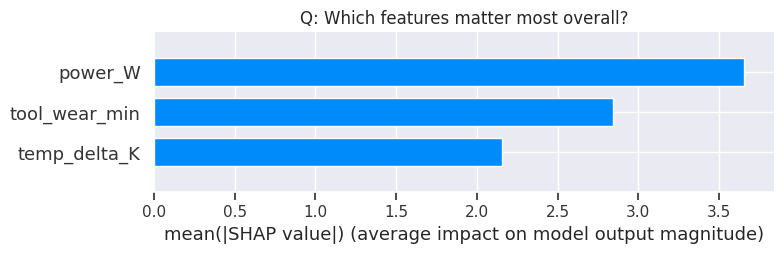

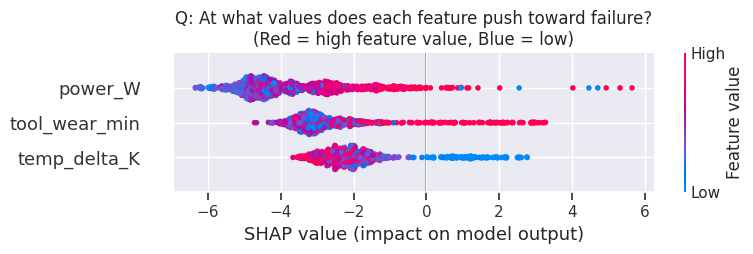

In [5]:
# Q: Which engineered features is the model actually using?
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Bar plot — overall importance
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Q: Which features matter most overall?')
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/shap_importance.png', dpi=150)
plt.show()

# Dot plot — direction and magnitude
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Q: At what values does each feature push toward failure?\n(Red = high feature value, Blue = low)')
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/shap_detail.png', dpi=150)
plt.show()

In [ ]:
# Q: Did feature engineering actually improve on raw features?
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer

df_raw = pd.read_csv('/home/james/ml-proj/predmain/data/ai4i2020.csv')
df_raw = df_raw.drop(columns=['UDI', 'Product ID', 'Type'], errors='ignore')

# XGBoost 3.x rejects column names containing [ ] or < — sanitise raw feature names
X_raw = df_raw[['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].copy()
X_raw.columns = ['air_temp_K', 'proc_temp_K', 'rot_speed_rpm', 'torque_Nm', 'tool_wear_min']
y_raw = df_raw['Machine failure']

# Engineered features for whole dataset (rename to avoid shadowing outer X)
df_eng = df_raw.copy()
from features import engineer_features as _eng
df_eng = _eng(df_eng)
X_eng = df_eng[get_feature_columns()]
y_eng = df_eng[get_target_column()]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mcc_scorer = make_scorer(matthews_corrcoef)

weight_full = get_class_weight(y_eng)
model_raw = build_model(scale_pos_weight=weight_full)
model_eng = build_model(scale_pos_weight=weight_full, **best_params)

mcc_raw = cross_val_score(model_raw, X_raw, y_raw, cv=skf, scoring=mcc_scorer)
mcc_eng_cv = cross_val_score(model_eng, X_eng, y_eng, cv=skf, scoring=mcc_scorer)
f1_raw  = cross_val_score(model_raw, X_raw, y_raw, cv=skf, scoring='f1')
f1_eng  = cross_val_score(model_eng, X_eng, y_eng, cv=skf, scoring='f1')

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(2)
width = 0.3

ax.bar(xpos - width/2, [mcc_raw.mean(), f1_raw.mean()], width,
       label='Raw features (5)', color='lightcoral',
       yerr=[mcc_raw.std(), f1_raw.std()], capsize=5)
ax.bar(xpos + width/2, [mcc_eng_cv.mean(), f1_eng.mean()], width,
       label='Engineered features (3)', color='steelblue',
       yerr=[mcc_eng_cv.std(), f1_eng.std()], capsize=5)

ax.set_xticks(xpos)
ax.set_xticklabels(['MCC', 'F1 Score'])
ax.set_ylabel('Score (higher = better)')
ax.set_title('Q: Did feature engineering improve the model?')
ax.legend()
ax.set_ylim(0, 1)

for i, (r, e) in enumerate(zip([mcc_raw.mean(), f1_raw.mean()],
                                [mcc_eng_cv.mean(), f1_eng.mean()])):
    ax.text(i - width/2, r + 0.02, f'{r:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, e + 0.02, f'{e:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/raw_vs_engineered.png', dpi=150)
plt.show()

print(f"MCC improvement: {mcc_eng_cv.mean() - mcc_raw.mean():+.4f}")
print(f"F1  improvement: {f1_eng.mean()  - f1_raw.mean():+.4f}")

Class weight (scale_pos_weight): 28.50
  (9661 no-failure rows vs 339 failure rows)


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/james/ml-proj/predmain/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/james/ml-proj/predmain/.venv/lib/python3.12/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/home/james/ml-proj/predmain/.venv/lib/python3.12/site-packages/xgboost/sklearn.py", line 1787, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/james/ml-proj/predmain/.venv/lib/python3.12/site-packages/xgbo

In [ ]:
# Save tuned model
MODEL_PATH = '/home/james/ml-proj/predmain/outputs/models/xgb_model.pkl'
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

print(f"\n{'='*50}")
print(f"Final model summary (threshold={THRESHOLD}):")
print(f"  Trees used (early stopping): {model.best_iteration}")
print(f"  Best Optuna params: {best_params}")
print(f"  Val  MCC: {val_metrics['mcc']:.3f}   F1: {val_metrics['f1']:.3f}")
print(f"  Test MCC: {test_metrics['mcc']:.3f}   F1: {test_metrics['f1']:.3f}")
print(f"{'='*50}")